# Gating a restored island

A restoration site is introduced to the grid behind a levee and opened gradually through
a hydraulic structure. Three inputs have to agree with one another for that to work:

1. the **structure**, whose node pairs and reference pair must not go dry,
2. the **dredge** at the opening, which gives those nodes somewhere to hold water, and
3. the **initial condition**, which must leave the island dry but pool the opening.

`schimpy.inundate_island` derives all three from two points per breach, and reuses one
polygon across them so they cannot drift apart. This notebook works a small synthetic
case end to end.

In addition to these requirements, the pool that keeps the island from flooding *may* be at risk of drying up due to evaporation. There are some hydraulic structure configurations that may help with that. A transfer, which is what is used here with $0m^3/s$, is thought to be less fragile

In [ ]:
import logging
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PolyCollection

from schimpy.ellipse import ellipse
from schimpy.inundate_island import (
    breach_axes,
    build_inundation_artifacts,
    validate_structures,
)
from schimpy.schism_mesh import read_mesh
from schimpy.schism_setup import create_schism_setup

logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger("inundate_demo")

workdir = Path(tempfile.mkdtemp(prefix="inundate_demo_"))
workdir

WindowsPath('C:/Users/eli/AppData/Local/Temp/inundate_demo_h2spo6nq')

## Example: A small leveed island

600 m by 500 m at 20 m spacing. A channel occupies the south, a subsided restoration
island the north. The levee between them is *not* meshed, so the two are joined only
through a single 80 m opening where a remnant sill sits above the water line.

Depths are positive down, as in the gr3 file, so the sill at `dp = -1.5` stands 1.5 m
above datum and the island bed at `dp = +0.8` lies 0.8 m below it.

In [ ]:
DX = 20.0
NX, NY = 31, 26          # nodes: 600 m by 500 m
LEVEE_ROW = 15           # element row spanning y 300-320, absent except at the gate
GATE_COLS = (13, 14, 15, 16)
GATE_X = (260.0, 340.0)

CHANNEL_DP = 4.0         # 4 m of water in the channel
ISLAND_DP = 0.8          # subsided: bed sits below datum, but behind a levee
SILL_DP = -1.5           # remnant levee at the opening, 1.5 m above datum


def build_demo_mesh(path):
    nodes = []
    for j in range(NY):
        for i in range(NX):
            x, y = i * DX, j * DX
            if GATE_X[0] <= x <= GATE_X[1] and y in (300.0, 320.0):
                dp = SILL_DP
            elif y <= 300.0:
                dp = CHANNEL_DP
            else:
                dp = ISLAND_DP
            nodes.append((x, y, dp))

    elems = []
    for j in range(NY - 1):
        for i in range(NX - 1):
            if j == LEVEE_ROW and i not in GATE_COLS:
                continue
            a = j * NX + i + 1
            elems.append((a, a + 1, a + NX + 1, a + NX))

    lines = ["inundate demo", f"{len(elems)} {len(nodes)} ! # of elements and nodes"]
    lines += [f"{k} {x:.8f} {y:.8f} {dp:.8f}" for k, (x, y, dp) in enumerate(nodes, 1)]
    lines += [f"{k} 4 {e[0]} {e[1]} {e[2]} {e[3]}" for k, e in enumerate(elems, 1)]
    path.write_text("\n".join(lines) + "\n")
    return path


hgrid = build_demo_mesh(workdir / "hgrid.gr3")
mesh = read_mesh(str(hgrid))
print(f"{mesh.n_nodes()} nodes, {mesh.n_elems()} elements")

806 nodes, 724 elements


In [ ]:
def element_patches(mesh):
    return [mesh.nodes[list(e), :2] for e in mesh.elems]


def node_to_elem(mesh, values):
    return np.array([np.mean(values[list(e)]) for e in mesh.elems])


def draw_field(ax, mesh, values, title, cmap="viridis", vmin=None, vmax=None):
    pc = PolyCollection(
        element_patches(mesh),
        array=node_to_elem(mesh, values),
        cmap=cmap,
        edgecolors="0.75",
        linewidths=0.2,
    )
    if vmin is not None:
        pc.set_clim(vmin, vmax)
    ax.add_collection(pc)
    ax.autoscale_view()
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
    return pc

## The two points

A breach follows the yaml rules for a hydraulic structure in the preprocessor. 
It is described by two points along the levee, ordered **left then right looking
into the island**. That ordering is not cosmetic: it decides which side of the structure
line is the island interior, and therefore which side the flood fill claims.

centre [300. 310.], along [1. 0.], into the island [-0.  1.]


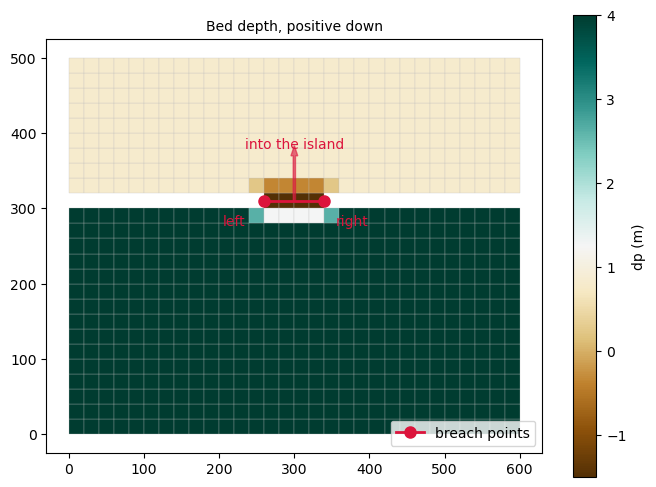

In [ ]:
LEFT = [260.0, 310.0]
RIGHT = [340.0, 310.0]
MAJOR_AXIS_LEN = 160.0   # full axis through the levee
DREDGE_PAD = 30.0        # dredge runs past the opening at each end
MIN_DEPTH = -0.3         # undisturbed ground at the rim of the footprint
MAX_DEPTH = 2.0          # dredged invert at the centre
FREEBOARD = 0.01
AMBIENT = 0.96

center, along, into = breach_axes(LEFT, RIGHT)
print(f"centre {center}, along {along}, into the island {into}")

fig, ax = plt.subplots(figsize=(8, 6))
draw_field(ax, mesh, mesh.nodes[:, 2], "Bed depth, positive down", cmap="BrBG")
ax.plot(*zip(LEFT, RIGHT), "o-", color="crimson", lw=2, ms=8, label="breach points")
ax.annotate("left", LEFT, textcoords="offset points", xytext=(-30, -18), color="crimson")
ax.annotate("right", RIGHT, textcoords="offset points", xytext=(8, -18), color="crimson")
ax.arrow(*center, *(into * 60), width=3, color="crimson", alpha=0.6)
ax.annotate("into the island", center + into * 70, color="crimson", ha="center")
ax.legend(loc="lower right")
plt.colorbar(ax.collections[0], ax=ax, label="dp (m)")
plt.show()

## Generating the inputs

`polygon: infer` walks the grid outward from a seed just inside the breach, treating the
elements the breach line crosses as barriers. Because the island touches the rest of the
grid only at the gate, the walk stops at the levee.

In [ ]:
islands = [
    {
        "name": "demo_island",
        "polygon": "infer",
        "breaches": [
            {
                "name": "gate",
                "left": LEFT,
                "right": RIGHT,
                "min_depth": MIN_DEPTH,
                "max_depth": MAX_DEPTH,
                "major_axis_len": MAJOR_AXIS_LEN,
                "dredge_pad": DREDGE_PAD,
                "structure": {"type": "transfer", "configuration": {"flow": 0.0}},
            }
        ],
    }
]

artifacts = build_inundation_artifacts(
    islands, mesh, freeboard=FREEBOARD, ambient=AMBIENT
)

dredge = artifacts["depth_enforcement"]["polygons"][0]
print(dredge["attribute"])
print()
for poly in artifacts["elevation"]["polygons"]:
    print(f"{poly['name']:>22}  type={poly['type']:<5} attribute={poly['attribute']}")

ellipse(x, y, z, [230.0, 310.0], [370.0, 310.0], min_depth=-0.300, max_depth=2.000, major_axis_len=160.0)

                domain  type=none  attribute=max(0.96, -z-0.01)
           demo_island  type=none  attribute=-z-0.01
      demo_island_gate  type=min   attribute=0.29


## What this looks like in yaml

The dict above is what the worker function takes. In practice the config is a file, and the
CLI reads it:

```
sch inundate_island --config breaches.yaml --hgrid hgrid.gr3 --out-dir .
```

Below is the same island as a config file, then the four files it produces. Vertex lists are
long, so they are elided here.


In [ ]:
from schimpy import schism_yaml
from schimpy.inundate_island import write_inundation_inputs


def show(text, label, elide_after=3):
    """Print yaml, collapsing long vertex lists to keep the output readable."""
    print(f"----- {label} " + "-" * max(0, 62 - len(label)))
    kept, skipped = [], 0
    for line in text.splitlines():
        stripped = line.strip()
        if stripped.startswith("- - ") or (stripped.startswith("- ") and stripped[2:].replace(".", "").replace("-", "").isdigit()):
            skipped += 1
            if skipped <= elide_after:
                kept.append(line)
            continue
        if skipped > elide_after:
            kept.append(f"{' ' * 4}... {skipped - elide_after} more vertex lines")
        skipped = 0
        kept.append(line)
    if skipped > elide_after:
        kept.append(f"{' ' * 4}... {skipped - elide_after} more vertex lines")
    print("\n".join(kept))
    print()


config_path = workdir / "breaches.yaml"
with open(config_path, "w") as fh:
    schism_yaml.safe_dump({"islands": islands}, fh, default_flow_style=False, sort_keys=False)
show(config_path.read_text(), "breaches.yaml (what you author)")

written = write_inundation_inputs(artifacts, str(workdir / "out"))
for key in ("structures", "depth_enforcement", "elevation", "regions"):
    show(Path(written[key]).read_text(), Path(written[key]).name)


----- breaches.yaml (what you author) -------------------------------
islands:
- name: demo_island
  polygon: infer
  breaches:
  - name: gate
    left:
    - 260.0
    - 310.0
    right:
    - 340.0
    - 310.0
    min_depth: -0.3
    max_depth: 2.0
    major_axis_len: 160.0
    dredge_pad: 30.0
    structure:
      type: transfer
      configuration:
        flow: 0.0

----- hydraulic_structures_inundate.yaml ----------------------------
# Generated by schimpy.inundate_island. Include alongside the base
# hydraulics file; this file deliberately carries no nudging value.
structures:
- name: demo_island_gate
  type: transfer
  end_points:
  - - 260.0
    - 310.0
  - - 340.0
    ... 1 more vertex lines
  configuration:
    flow: 0.0
  reference: self

----- depth_enforce_inundate.yaml -----------------------------------
# Generated by schimpy.inundate_island.
# Requires 'schimpy.ellipse.ellipse' among the preprocessor imports.
polygons:
- name: demo_island_gate
  type: none
  attribute:

The pool level is not a free parameter. `ellipse` clamps its radial term at 1, so every
node inside the polygon comes out at `min_depth` or deeper. That makes
`-min_depth - freeboard` a water level meeting the island's `-z - freeboard` exactly at
the rim, with no step between them.

In [ ]:
pool = -MIN_DEPTH - FREEBOARD
print(f"pool level        {pool:+.3f} m")
print(f"at the rim  H =   {MIN_DEPTH + pool:+.3f} m  (dry by the freeboard)")
print(f"at the invert H = {MAX_DEPTH + pool:+.3f} m  (a pool at the gate)")
print(f"ambient           {AMBIENT:+.3f} m, so a 'min' bound leaves the channel alone")

pool level        +0.290 m
at the rim  H =   -0.010 m  (dry by the freeboard)
at the invert H = +2.290 m  (a pool at the gate)
ambient           +0.960 m, so a 'min' bound leaves the channel alone


## Polygon and ellipse

The ring is the ellipse scaled out slightly, rather than a bounding box, so it encloses
the taper without sweeping in corners that would be dredged for no reason. The dredge
runs `dredge_pad` past the opening at each end so the structure's own end nodes and its
reference pair land on dredged ground.

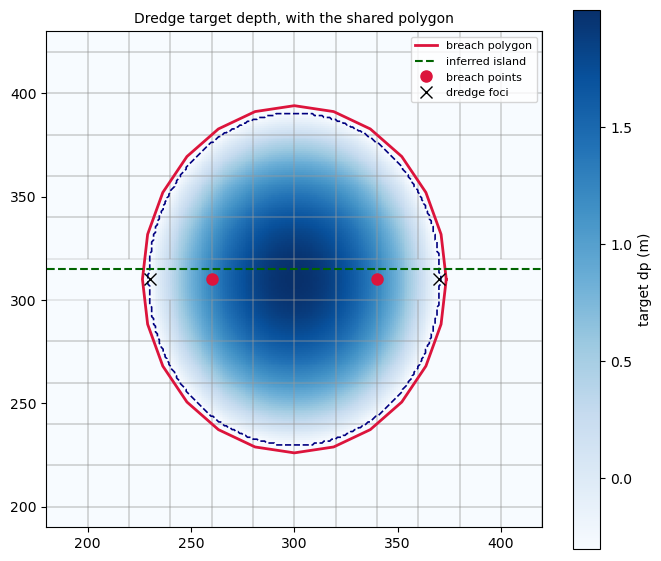

In [ ]:
dredge_left = np.asarray(LEFT) - along * DREDGE_PAD
dredge_right = np.asarray(RIGHT) + along * DREDGE_PAD

gx, gy = np.meshgrid(np.linspace(180, 420, 260), np.linspace(190, 430, 260))
target = ellipse(
    gx, gy, np.full_like(gx, -99.0), dredge_left, dredge_right,
    min_depth=MIN_DEPTH, max_depth=MAX_DEPTH, major_axis_len=MAJOR_AXIS_LEN,
)

ring = np.array(dredge["vertices"])
island_ring = np.array(
    [p for p in artifacts["elevation"]["polygons"] if p["name"] == "demo_island"][0][
        "vertices"
    ]
)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.pcolormesh(gx, gy, target, cmap="Blues", shading="auto")
ax.contour(gx, gy, target, levels=[MIN_DEPTH + 1e-6], colors="navy", linewidths=1.2)
pc = PolyCollection(
    element_patches(mesh), facecolors="none", edgecolors="0.6", linewidths=0.3
)
ax.add_collection(pc)
ax.plot(ring[:, 0], ring[:, 1], "-", color="crimson", lw=2, label="breach polygon")
ax.plot(island_ring[:, 0], island_ring[:, 1], "--", color="darkgreen", lw=1.5, label="inferred island")
ax.plot(*zip(LEFT, RIGHT), "o", color="crimson", ms=8, label="breach points")
ax.plot(*zip(dredge_left, dredge_right), "x", color="black", ms=9, label="dredge foci")
ax.set_xlim(180, 420)
ax.set_ylim(190, 430)
ax.set_aspect("equal")
ax.set_title("Dredge target depth, with the shared polygon", fontsize=10)
ax.legend(loc="upper right", fontsize=8)
plt.colorbar(im, ax=ax, label="target dp (m)")
plt.show()

The navy contour is the ellipse itself. Outside it the target flattens to `min_depth`,
which is why the polygon can sit slightly proud of the ellipse without introducing a
discontinuity.

## Before and after: the bed

Applying the generated depth enforcement the way `prepare_schism` will.

deepened at 18 nodes, max cut 3.46 m
shallowed anywhere: False


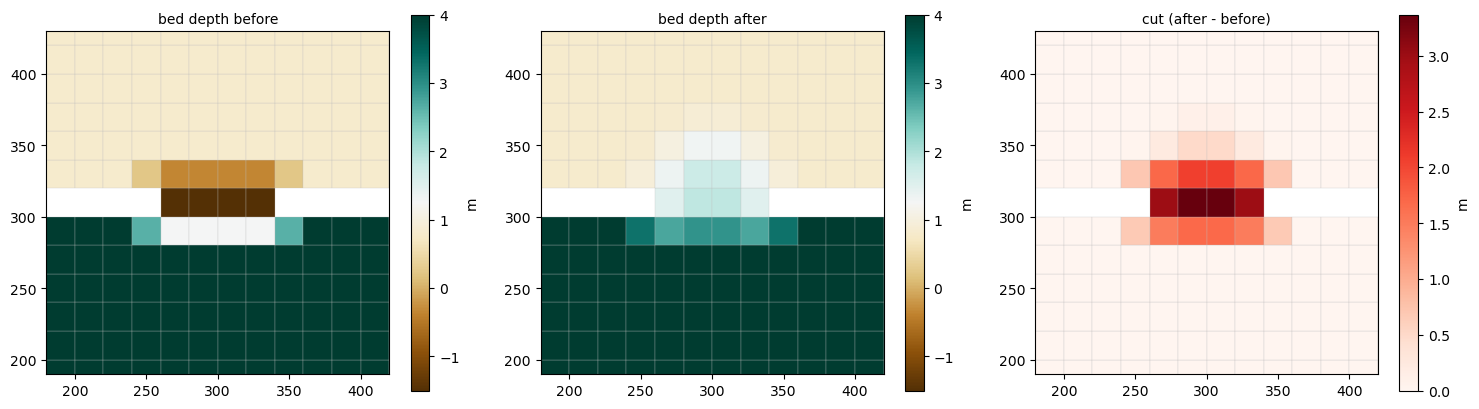

In [ ]:
setup = create_schism_setup(str(hgrid), logger)
dp_before = setup.mesh.nodes[:, 2].copy()

dp_after = setup.apply_polygons(
    polygons=artifacts["depth_enforcement"]["polygons"],
    default=None,
    global_imports=["schimpy.ellipse.ellipse"],
)
setup.mesh.nodes[:, 2] = dp_after

cut = dp_after - dp_before
print(f"deepened at {np.count_nonzero(cut > 1e-9)} nodes, max cut {cut.max():.2f} m")
print(f"shallowed anywhere: {bool(np.any(cut < -1e-9))}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
lim = (min(dp_before.min(), dp_after.min()), max(dp_before.max(), dp_after.max()))
for ax, vals, title in zip(
    axes, [dp_before, dp_after, cut], ["before", "after", "cut (after - before)"]
):
    if title.startswith("cut"):
        pc = draw_field(ax, mesh, vals, title, cmap="Reds")
    else:
        pc = draw_field(ax, mesh, vals, f"bed depth {title}", cmap="BrBG", vmin=lim[0], vmax=lim[1])
    ax.set_xlim(180, 420)
    ax.set_ylim(190, 430)
    plt.colorbar(pc, ax=ax, label="m")
plt.tight_layout()
plt.show()

The sill is cut down; nothing is made shallower, because `ellipse` never returns a value
above the existing bed. The deep channel inside the footprint is left as it was.

## Before and after: the water surface

`elev.ic` is built from the same polygons, in order. The domain entry puts the surface at
ambient unless that would be below the bed; the island entry forces the whole restoration
area dry; the breach entry is a **lower bound**, so it pools the dredged opening while
leaving both ambient water and dry ground untouched.

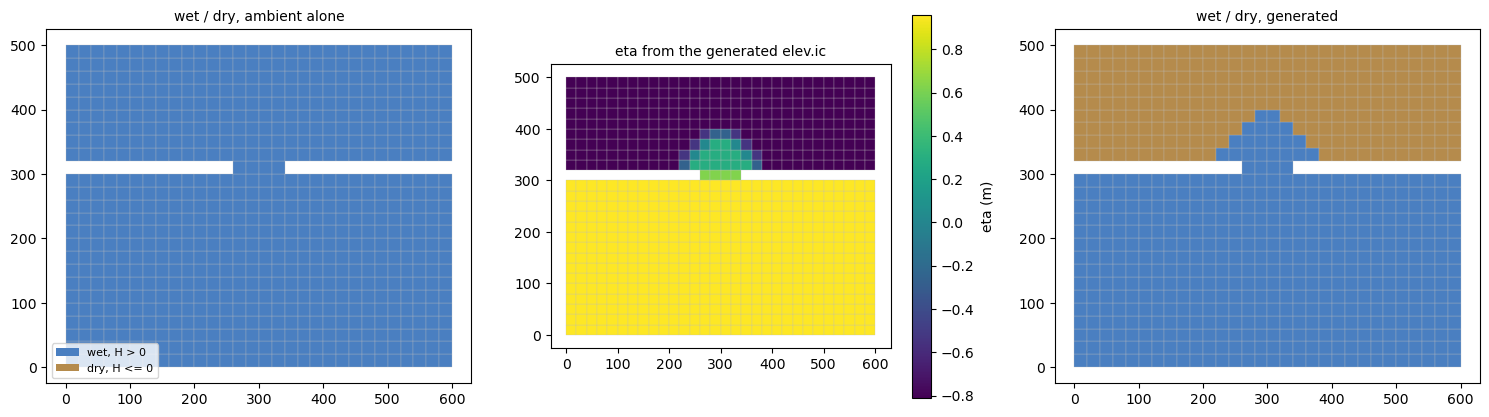

island total depth, ambient alone: +1.760 m
island total depth, generated:     +0.005 m


In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

eta_naive = np.maximum(AMBIENT, -dp_after - FREEBOARD)   # ambient only, no island entry
eta = setup.apply_polygons(
    polygons=artifacts["elevation"]["polygons"], default=AMBIENT
)

h_naive = dp_after + eta_naive
h = dp_after + eta

# the island ends up dry by only the freeboard, which no depth scale that also has
# to hold a 5 m channel can show, so plot the wet/dry state itself
wetdry = ListedColormap(["#b58b4c", "#4a7fc1"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, vals, title in [
    (axes[0], h_naive, "wet / dry, ambient alone"),
    (axes[2], h, "wet / dry, generated"),
]:
    pc = draw_field(ax, mesh, (vals > 0).astype(float), title, cmap=wetdry)
    pc.set_clim(0, 1)
axes[0].legend(
    handles=[
        Patch(facecolor="#4a7fc1", label="wet, H > 0"),
        Patch(facecolor="#b58b4c", label="dry, H <= 0"),
    ],
    loc="lower left",
    fontsize=8,
)

pc = draw_field(axes[1], mesh, eta, "eta from the generated elev.ic", cmap="viridis")
plt.colorbar(pc, ax=axes[1], label="eta (m)")

plt.tight_layout()
plt.show()

interior = mesh.nodes[:, 1] > 440   # clear of the pool that reaches back from the gate
print(f"island interior, ambient alone: H = {h_naive[interior].mean():+.3f} m")
print(f"island interior, generated:     H = {h[interior].mean():+.3f} m")
print(f"dry share of the whole island:  {np.mean(h[mesh.nodes[:, 1] > 320] <= 0):.0%}")


Three panels, and the **outer two are the pair to compare**. Both show total depth
`H = dp + eta` on one shared scale. The middle panel is a different quantity entirely,
with its own scale.

Reading the outer two: they use a diverging map clipped symmetrically at ±2 m, so **blue
is water, red is dry, and white falls exactly at `H = 0`** — the wetting and drying line
itself. Anywhere the colour turns from blue to red, the bed has come out of the water.

**Left — ambient alone.** What `max(ambient, -z - freeboard)` gives with no island entry.
The island reads blue: it has flooded, because its subsided bed at `dp = +0.8` sits below
the ambient level of 0.96 m. Water has appeared behind a levee that has not been opened
yet, which is the outcome the island polygon exists to prevent.

**Middle — the initial surface itself.** This is `eta`, the quantity `elev.ic` actually
carries, not a depth, so it gets a sequential map and its own scale. It settles into three
plateaus: the channel at ambient, the island tracking its own bed one freeboard below it,
and the opening at the pool level. The abrupt step between island and channel is the point
rather than an artefact — neighbouring nodes can differ by more than a metre of `eta` and
both be right, because one is dry and the other is not.

**Right — what the generator produces.** The same total depth as the left panel, after the
island and breach entries are applied. The island has turned red, so it is dry; the channel
is unchanged; and a small blue patch remains at the gate, the pool that keeps the
structure's nodes wet.


In [ ]:
def region_report(name, sel):
    print(
        f"{name:<26} dp {dp_after[sel].mean():+6.2f}   eta {eta[sel].mean():+6.2f}"
        f"   H {h[sel].mean():+6.2f}   {'wet' if h[sel].mean() > 0 else 'dry'}"
    )


xy = mesh.nodes[:, :2]
in_ring = np.array(
    [
        (((p[0] - center[0]) / 70.0) ** 2 + ((p[1] - center[1]) / 80.0) ** 2) < 1.0
        for p in xy
    ]
)
region_report("channel, away from gate", (xy[:, 1] < 260) & ~in_ring)
region_report("island interior", (xy[:, 1] > 360) & ~in_ring)
region_report("the opening", in_ring & (np.abs(xy[:, 1] - 310) < 25))

channel, away from gate    dp  +4.00   eta  +0.96   H  +4.96   wet
island interior            dp  +0.80   eta  -0.81   H  -0.01   dry
the opening                dp  +1.82   eta  +0.62   H  +2.45   wet


## Validation

The structure is built the way the preprocessor will build it, and every node pair and
the reference pair are checked against the same polygon that dredges the opening. A
reference node outside it would sit on undredged ground and could go dry, which is the
failure this whole arrangement exists to avoid.

In [ ]:
checked = validate_structures(artifacts, str(hgrid), logger=logger)
print(checked)

Processing structure: demo_island_gate


Structure demo_island_gate: 5 node pairs, reference pair inside the dredge polygon


{'demo_island_gate': 12}


Processing structure: demo_island_gate


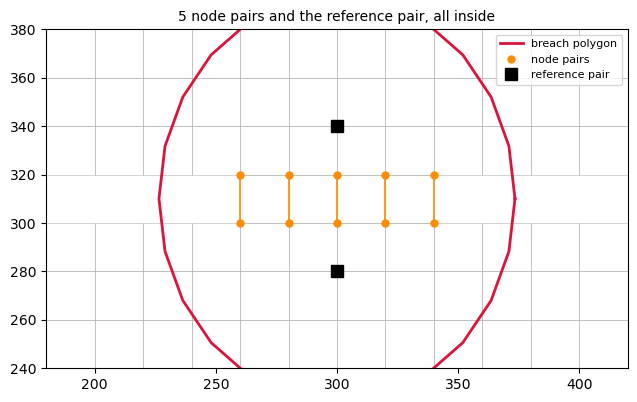

In [ ]:
fresh = create_schism_setup(str(hgrid), logger)
fresh.create_structures(artifacts["structures"]["structures"])
built = fresh._input.structures[0]
pairs = np.array([[fresh.mesh.nodes[a][:2], fresh.mesh.nodes[b][:2]] for a, b in built.node_pairs])
refs = np.array([fresh.mesh.nodes[n][:2] for n in built.reference_pair])

fig, ax = plt.subplots(figsize=(7.5, 6.5))
pc = PolyCollection(element_patches(mesh), facecolors="none", edgecolors="0.7", linewidths=0.4)
ax.add_collection(pc)
ax.plot(ring[:, 0], ring[:, 1], color="crimson", lw=2, label="breach polygon")
for seg in pairs:
    ax.plot(seg[:, 0], seg[:, 1], "-", color="darkorange", lw=1.2)
ax.plot(pairs[:, :, 0].ravel(), pairs[:, :, 1].ravel(), "o", color="darkorange", ms=5, label="node pairs")
ax.plot(refs[:, 0], refs[:, 1], "s", color="black", ms=9, label="reference pair")
ax.set_xlim(180, 420)
ax.set_ylim(240, 380)
ax.set_aspect("equal")
ax.set_title(f"{len(built.node_pairs)} node pairs and the reference pair, all inside", fontsize=10)
ax.legend(loc="upper right", fontsize=8)
plt.show()

## What to carry away

- Two points per breach, ordered looking into the island, drive everything else.
- One polygon is emitted per breach and reused across the dredge, the initial condition
  and the hotstart regions, so consistency is structural rather than a convention.
- The pool level follows from `min_depth`, so the initial surface meets the island
  treatment exactly at the rim of the footprint.
- The fill starts from the island-side reference node each structure will itself use, so
  the polygon and the structure cannot disagree about which side the island is on.
- Ordering is load bearing in `elev.ic`: the breach entry is a lower bound and must come
  after the island entry. The generated file carries a comment saying so.


## Limitations

**`min_depth` must describe ground, not the levee crest.** The breach entry is a lower
bound, which is what lets it pool the opening without disturbing the channel — but only
while the pool level `-min_depth - freeboard` stays below ambient. Choose a `min_depth`
well above the water line and the bound will raise the channel side too, flooding outward
from the gate instead of pooling within it. Pick it to describe ordinary ground at the rim
of the dredge footprint.

**An island with an interior hole loses it.** `_fill_outline` traces the boundary of the
filled elements and keeps the longest ring. A restoration area enclosing a borrow pit, an
unmeshed structure footprint or an interior island would have that hole discarded, so the
outline would cover ground the fill never claimed. Fine for a simple perimeter; do not
rely on the polygon for area.

**The 50 percent fill guard is a heuristic.** It catches a fill that escapes past the
levee, but only after the walk has already run over much of the mesh, and the threshold is
arbitrary. On a mesh where the restoration area is a large share of the domain it will fire
on a perfectly good island. When it does, give the polygon explicitly rather than raising
the limit — an escaping fill usually means the levee is not closed in the grid, which is
worth knowing about.

**The dredge is specified, not computed.** `min_depth` and `max_depth` are absolute target
depths you supply per breach. Nothing checks them against the surrounding bathymetry or
against the flow the structure is meant to pass, so a plausible-looking pair can still give
an opening too shallow to convey anything.

**None of this has been through a real run.** The geometry, the layering and the structure
resolution are all exercised on synthetic cases like this one, which confirms they are
self-consistent. What remains untested is `prepare_schism` on a production Bay-Delta mesh,
a hotstart built from the generated `elev.ic`, and a SCHISM run confirming the gates never
trip the rule against dry structure nodes.
